In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor

In [3]:
df = pd.read_csv("used_device_data.csv")
df.head()

,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of dataset: (3463, 15)

Column names:
Index(['device_brand', 'os', 'screen_size', '4g', '5g', 'rear_camera_mp',
       'front_camera_mp', 'internal_memory', 'ram', 'battery', 'weight',
       'release_year', 'days_used', 'normalized_used_price',
       'normalized_new_price'],
      dtype='object')

Data types:
device_brand              object
os                        object
screen_size              float64
4g                        object
5g                        object
rear_camera_mp           float64
front_camera_mp          float64
internal_memory          float64
ram                      float64
battery                  float64
weight                   float64
release_year               int64
days_used                  int64
normalized_used_price    float64
normalized_new_price     float64
dtype: object


In [5]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 9


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (3454, 15)


In [7]:
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percent
})

print(missing_table[missing_table["Missing Count"] > 0])

                 Missing Count  Missing Percentage
os                           3            0.086856
rear_camera_mp             179            5.182397
front_camera_mp              2            0.057904
internal_memory              4            0.115808
ram                          4            0.115808
battery                      6            0.173712
weight                       7            0.202664


In [8]:
small_missing_numeric_cols = ["front_camera_mp", "internal_memory", "ram", "battery", "weight"]

for col in small_missing_numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

In [9]:
df["os"] = df["os"].fillna(df["os"].mode()[0])

In [10]:
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percent
})

print(missing_table[missing_table["Missing Count"] > 0])

                Missing Count  Missing Percentage
rear_camera_mp            179            5.182397


In [11]:
features = ["front_camera_mp", "device_brand", "4g", "release_year", "ram", "battery"]
target = "rear_camera_mp"

In [12]:
train_df = df[df[target].notna()].copy()
missing_df = df[df[target].isna()].copy()

print("Rows with known rear_camera_mp:", train_df.shape[0])
print("Rows with missing rear_camera_mp:", missing_df.shape[0])

Rows with known rear_camera_mp: 3275
Rows with missing rear_camera_mp: 179


In [13]:
X_train = train_df[features]
y_train = train_df[target]
X_missing = missing_df[features]

In [14]:
numeric_features = ["front_camera_mp", "release_year", "ram", "battery"]
categorical_features = ["device_brand", "4g"]

In [15]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [16]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [17]:
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", KNeighborsRegressor(n_neighbors=5, weights="distance"))
])

In [18]:
knn_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [19]:
predicted_values = knn_model.predict(X_missing)
predicted_values[:10]

array([ 9.50120189, 12.61531874,  9.37559842, 10.79415005,  8.76739537,
        3.382068  , 11.4008313 , 13.        , 10.85497736, 10.29713795])

In [20]:
df.loc[df[target].isna(), target] = np.round(predicted_values, 2)

In [21]:
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percent
})

print(missing_table)

                       Missing Count  Missing Percentage
device_brand                       0                 0.0
os                                 0                 0.0
screen_size                        0                 0.0
4g                                 0                 0.0
5g                                 0                 0.0
rear_camera_mp                     0                 0.0
front_camera_mp                    0                 0.0
internal_memory                    0                 0.0
ram                                0                 0.0
battery                            0                 0.0
weight                             0                 0.0
release_year                       0                 0.0
days_used                          0                 0.0
normalized_used_price              0                 0.0
normalized_new_price               0                 0.0


In [22]:
print("Final shape:", df.shape)
print("\nFinal data types:")
print(df.dtypes)

Final shape: (3454, 15)

Final data types:
device_brand              object
os                        object
screen_size              float64
4g                        object
5g                        object
rear_camera_mp           float64
front_camera_mp          float64
internal_memory          float64
ram                      float64
battery                  float64
weight                   float64
release_year               int64
days_used                  int64
normalized_used_price    float64
normalized_new_price     float64
dtype: object


In [23]:
df.head()

,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [24]:
df.to_csv("preprocessed_used_device_data.csv", index=False)
print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


--- SVM Model Evaluation ---
R-squared (R2) Score: 0.8442
Mean Absolute Error (MAE): 0.1756
Mean Squared Error (MSE): 0.0506


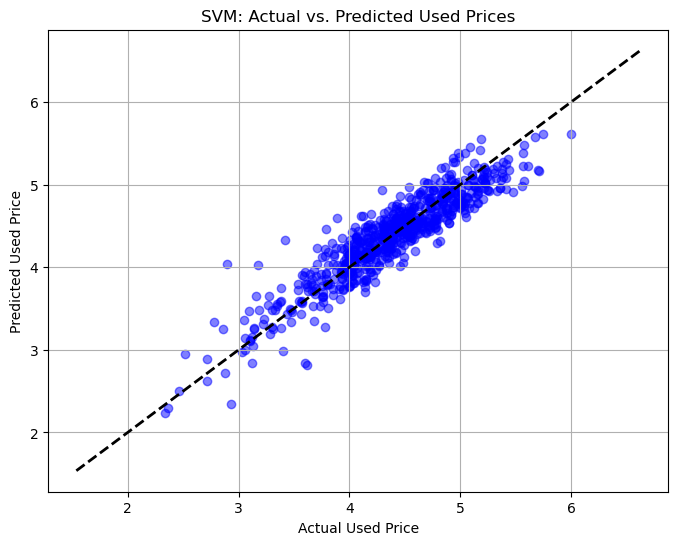

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

#Load the preprocessed data
df = pd.read_csv('preprocessed_ml_project.csv')

#Separate features (X) and target (y)
# We are trying to predict 'normalized_used_price'
X = df.drop('normalized_used_price', axis=1)
y = df['normalized_used_price']

#Identify categorical and numerical columns for preprocessing
categorical_cols = ['device_brand', 'os', '4g', '5g']
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Create a preprocessing step: Scale numbers and Encode text
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

#Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Create the SVM Pipeline using the RBF Kernel
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

#Train the SVM model
svm_pipeline.fit(X_train, y_train)

#Test the model to see how well it learned
y_pred = svm_pipeline.predict(X_test)

#Evaluate the results
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("--- SVM Model Evaluation ---")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

#Plot Predicted vs Actual prices for your report!
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # 45-degree line
plt.xlabel('Actual Used Price')
plt.ylabel('Predicted Used Price')
plt.title('SVM: Actual vs. Predicted Used Prices')
plt.grid(True)
plt.savefig('svm_predictions_plot.png')
plt.show()